In [1]:
#used to allow importing of physicsnemo
import sys
sys.path.append("/global/u2/k/kfrields/climsim-kaggle-edition")
from physicsnemo.models.diffusion import *
from baseline_models.unet.training_default.climsim_datasets import *
import numpy as np
from sklearn.metrics import r2_score
import torch
import os, gc
from climsim_utils.data_utils import *
from tqdm import tqdm
from matplotlib import cm
import torch
import statsmodels.api as sm # For QQ plot
from baseline_models.unet.training_default.joint_model import JointModel
from omegaconf import OmegaConf
from torch.utils.data import Dataset, DataLoader

## Set up Residual Model

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = torch.device('cpu')

## Set up Data

In [3]:
def apply_temperature_rules(T):
    # Create an output tensor, initialized to zero
    output = np.zeros_like(T)

    # Apply the linear transition within the range 253.16 to 273.16
    mask = (T >= 253.16) & (T <= 273.16)
    output[mask] = (T[mask] - 253.16) / 20.0  # 20.0 is the range (273.16 - 253.16)

    # Values where T > 273.16 set to 1
    output[T > 273.16] = 1

    # Values where T < 253.16 are already set to 0 by the initialization
    return output

def preprocessing_v2_rh_mc(data, input_path, target_path, input_sub, input_div, lbd_qn, out_scale):
    npy_input = np.load(input_path)
    npy_target = np.load(target_path)
    
    surface_pressure = npy_input[:, data.ps_index]
    
    hyam_component = (data.hyam * data.p0)[np.newaxis,:]
    hybm_component = data.hybm[np.newaxis,:] * surface_pressure[:, np.newaxis]
    
    pressures = hyam_component + hybm_component
    pressures = pressures.reshape(-1,384,60)
    
    pressures_binned = data.zonal_bin_weight_3d(pressures)
    
    actual_input = npy_input.copy().reshape(-1, data.num_latlon, data.input_feature_len)
    
    npy_input[:,120:180] = 1 - np.exp(-npy_input[:,120:180] * lbd_qn)
    npy_input = (npy_input - input_sub)/input_div
    npy_input = np.where(np.isnan(npy_input), 0, npy_input)
    npy_input = np.where(np.isinf(npy_input), 0, npy_input)
    npy_input[:,120:120+15] = 0
    npy_input[:,60:120] = np.clip(npy_input[:,60:120], 0, 1.2)
    torch_input = torch.tensor(npy_input).float()
    
    reshaped_target = npy_target.reshape(-1, data.num_latlon, data.target_feature_len)
    '''
    t_before = actual_input[:, :, 0:60]
    qn_before = actual_input[:, :, 120:180]
    liq_frac_before = apply_temperature_rules(t_before)
    qc_before = liq_frac_before * qn_before
    qi_before = (1 - liq_frac_before) * qn_before

    t_new = t_before + reshaped_target[:, :, 0:60]*1200
    qn_new = qn_before + reshaped_target[:, :, 120:180]*1200
    liq_frac_new = apply_temperature_rules(t_new)
    qc_new = liq_frac_new * qn_new
    qi_new = (1 - liq_frac_new) * qn_new
    
    actual_target = np.concatenate((reshaped_target[:, :, 0:120], 
                                    (qc_new - qc_before)/1200, 
                                    (qi_new - qi_before)/1200, 
                                    reshaped_target[:, :, 180:240], 
                                    reshaped_target[:, :, 240:]), axis=2)
                                    '''
    return torch_input, actual_input, reshaped_target, pressures_binned

In [27]:

base_path = '/pscratch/sd/k/kfrields/hugging/E3SM-MMF_saved_models/diffusion_models/cross_attention_test/'

def load_model(config_path):
    with open(config_path, "r") as f:
        cfg=OmegaConf.load(f)
    base_path = os.path.join(cfg.save_path, cfg.expname)

    v2_rh_mc_input_path =  '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/val_set/val_input.npy'
    v2_rh_mc_target_path = '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/val_set/val_target.npy'

    #============creates normalization metrics========
    grid_info = xr.open_dataset(cfg.grid_info_path)
    input_mean = xr.open_dataset(cfg.input_mean_path)
    input_max = xr.open_dataset(cfg.input_max_path)
    input_min = xr.open_dataset(cfg.input_min_path)
    output_scale = xr.open_dataset(cfg.output_scale_path)
    qn_lbd = np.loadtxt(cfg.qn_lbd_path, delimiter = ',')
    
    res_std = torch.load(cfg.res_std_path).to(device)
    res_std = res_std.to(torch.float32)
    
    res_mean = torch.load(cfg.res_mean_path).to(device)
    res_mean = res_mean.to(torch.float32)
    
    preds_std = torch.load(cfg.preds_std_path).to(device)
    preds_std = preds_std.to(torch.float32)
    
    preds_mean = torch.load(cfg.preds_mean_path).to(device)
    preds_mean = preds_mean.to(torch.float32)
    
    data = data_utils(grid_info = grid_info, 
                      input_mean = input_mean, 
                      input_max = input_max, 
                      input_min = input_min, 
                      output_scale = output_scale,
                      qinput_log = False,
                      normalize = False,
                      res_std = res_std,
                      res_mean = res_mean,
                      preds_std = preds_std,
                      preds_mean = preds_mean)
    data.set_to_v2_rh_mc_vars()
    
    input_sub_v2_rh_mc, input_div_v2_rh_mc, out_scale_v2_rh_mc = data.save_norm(write=False) # this extracts only the relevant variables
    input_sub_v2_rh_mc = input_sub_v2_rh_mc[None, :]
    input_div_v2_rh_mc = input_div_v2_rh_mc[None, :]
    out_scale_v2_rh_mc = out_scale_v2_rh_mc[None, :]


    deterministic_model_path = os.path.join(base_path, 'unet_model.pt')
    deterministic_model = torch.jit.load(deterministic_model_path).to(device)
    deterministic_model.eval()
    
    #Load residual model
    diff_path = os.path.join(base_path, 'diff_model.pt')
    diff_model = torch.load(diff_path).to(device)
    diff_model.eval()

    if cfg.diffusion_model.condition_location == 'embedding':
        if cfg.diffusion_model.condition_type == 'input_output':
            cond_channels = (data.target_profile_num  + data.target_scalar_num + data.input_profile_num + data.input_scalar_num)*64
        else:
            cond_channels = 8192
    elif cfg.diffusion_model.condition_location == 'middle':
        if cfg.diffusion_model.condition_type == 'input_output':
            cond_channels = data.target_profile_num  + data.target_scalar_num + data.input_profile_num + data.input_scalar_num
    elif cfg.diffusion_model.condition_location == 'cross':
        if cfg.diffusion_model.condition_type == 'input_output':
            cond_channels = data.target_profile_num  + data.target_scalar_num + data.input_profile_num + data.input_scalar_num
            
    
    joint_model = JointModel(deterministic_model,diff_model, res_std, res_mean, 
                                preds_std, preds_mean, 
                                input_profile_num = data.input_profile_num, 
                                input_scalar_num = data.input_scalar_num,
                                target_profile_num = data.target_profile_num,
                                target_scalar_num = data.target_scalar_num, 
                                condition_channel_num = cond_channels,
                                condition_type = cfg.diffusion_model.condition_type,
                                condtition_location=cfg.diffusion_model.condition_location,
                                p_mean = cfg.diffusion_model.p_mean,
                                p_std = cfg.diffusion_model.p_std,
                                t_sampling = False).to(device)
    
    torch_input, actual_input, actual_target, pressures_binned = preprocessing_v2_rh_mc(data = data, 
                                                                          input_path = v2_rh_mc_input_path, 
                                                                          target_path = v2_rh_mc_target_path, 
                                                                          input_sub = input_sub_v2_rh_mc, 
                                                                          input_div = input_div_v2_rh_mc, 
                                                                          lbd_qn = qn_lbd, 
                                                                          out_scale = out_scale_v2_rh_mc)
    torch_target = torch.tensor(actual_target)
    
    #return joint_model,data, torch_input_v2_rh_mc, actual_input_v2_rh_mc, out_scale_v2_rh_mc, actual_target, pressures_binned, reshaped_target, original_target
    return joint_model, actual_input, torch_input, torch_target, pressures_binned, data, out_scale_v2_rh_mc
    


In [28]:

config_path = '/pscratch/sd/k/kfrields/hugging/E3SM-MMF_saved_models/diffusion_models/cross_attention_test/saved_config.yaml'


joint_model, actual_input, torch_input, actual_target, pressures_binned, data, out_scale = load_model(config_path)

/tmp/ipykernel_2016322/1811098425.py:32: RuntimeWarning: divide by zero encountered in divide
  npy_input = (npy_input - input_sub)/input_div


In [67]:
joint_model.p_std 


In [29]:
'''
torch_input (B, C*L)
target (B, C*L)
'''

def inference_joint_model(joint_model, torch_input, actual_input, target, pressures_binned,data,output_scale, debug_batch_override = None):
    #Load deterministic model
    joint_model.deterministic_model.eval()
    joint_model.res_model.eval()
    
    
    det_list = []
    joint_list = []
    res_list = []

    #plain_det_list = []
    #plain_joint_list = []

    batch_size = data.num_latlon

    batch_i = 0
    
    with torch.no_grad():
        for i in tqdm(range(0, torch_input.shape[0], batch_size)):
            input_batch = torch_input[i : i + batch_size, :].to(device)
            target_batch = target[i : i + batch_size, :].cpu()
            if debug_batch_override != None and batch_i >= debug_batch_override:
                break
            batch_i += 1
            
            #(B, C*L) --> (B,C,L)
            input_batch = joint_model.reshape_input(input_batch)

            #(B,C,L) 
            output, latent_output = joint_model.deterministic_model(input_batch)

     
            #======Normalize input and condition data======
            safe_std = torch.clamp(joint_model.res_std, min=1e-2)
            
            condition_output = ((output -joint_model.preds_mean)/((joint_model.preds_std + 1e-8)))*.5
            #condition_data = torch.cat((condition_output, input_batch), dim = 1)
            #latent_condition = latent_condition.reshape(latent_condition.shape[0], -1)
            #condition_data = latent_condition
            
            if joint_model.condition_location == 'embedding':
                if joint_model.condition_type == 'input_output':
                    latent_condition = torch.cat((input_batch, condition_output), dim=1)
                else:
                    latent_condition = latent_output
                condition_data = latent_condition.reshape(latent_condition.shape[0], -1)
                
            elif joint_model.condition_location == 'middle' or joint_model.condition_location == 'cross':
                print('went here')
                if joint_model.condition_type == 'input_output':
                    latent_condition = torch.cat((input_batch, condition_output), dim=1)
                    print(latent_condition.shape)
                condition_data = latent_condition
        
            #latents (B, C,L)
            print(condition_data.shape)
            latents = torch.randn((batch_size, data.target_profile_num + data.target_scalar_num, 64))
            latents = latents.to(device)
        
            
            # res shape (B, C, L)
            res = joint_model.res_model.edm_sampler(latents, condition_input = condition_data, device = device, sigma_min=0.1, sigma_max=45, rho = 7) #maybe have to remove the last 4 meaningless levels??
            #rezeroes stratosphere levels
            
            #print(f'res shape is {res.shape}')
            denormalized_predicted_residual = (res/.5)*((safe_std+ 1e-8))
            #(B,C,L) --> (B, C*L)
            reshaped_res = joint_model.reverse_reshape_target(denormalized_predicted_residual)
            
            #(B,C,L) --> (B, C*L)
            output = joint_model.reverse_reshape_target(output)
            #print(f'output shape is {output.shape}')
            
            joint_pred = output + reshaped_res
            joint_pred[:, 300:] = torch.nn.functional.relu(torch.tensor(joint_pred[:, 300:]))
            #print(joint_pred[:, 300:])

            output = (output.cpu()/output_scale).numpy()
            det_list.append(output)
            
            reshaped_res = (reshaped_res.cpu()/output_scale).numpy()
            res_list.append(reshaped_res)

            
            #(B,C,L) --> (B, C*L)
            #joint_pred = joint_model.reverse_reshape_target(joint_pred)
            joint_pred = (joint_pred.cpu()/output_scale).numpy()
            joint_list.append(joint_pred)
            
    det_stack = np.stack(det_list, axis=0)
    res_stack = np.stack(res_list, axis= 0)
    joint_stack = np.stack(joint_list, axis=0)


    gc.collect()
    torch.cuda.empty_cache()

    return det_stack, joint_stack, res_stack


In [30]:
det_preds, joint_preds, res_stack = inference_joint_model(joint_model, torch_input,actual_input, torch.tensor(actual_target.reshape(-1, 308)), pressures_binned, data,out_scale,                      
                                        debug_batch_override = 5)

/tmp/ipykernel_2016322/2391144049.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  det_preds, joint_preds, res_stack = inference_joint_model(joint_model, torch_input,actual_input, torch.tensor(actual_target.reshape(-1, 308)), pressures_binned, data,out_scale,
  0%|          | 0/3754 [00:00<?, ?it/s]

went here
torch.Size([384, 39, 64])
torch.Size([384, 39, 64])


/tmp/ipykernel_2016322/651870166.py:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  joint_pred[:, 300:] = torch.nn.functional.relu(torch.tensor(joint_pred[:, 300:]))
  0%|          | 1/3754 [00:02<2:37:04,  2.51s/it]

went here
torch.Size([384, 39, 64])
torch.Size([384, 39, 64])


  0%|          | 2/3754 [00:05<2:48:23,  2.69s/it]

...

  0%|          | 3/3754 [00:07<2:20:03,  2.24s/it]

went here
torch.Size([384, 39, 64])
torch.Size([384, 39, 64])


  0%|          | 4/3754 [00:08<2:06:38,  2.03s/it]

went here
torch.Size([384, 39, 64])
torch.Size([384, 39, 64])


  0%|          | 5/3754 [00:10<2:10:29,  2.09s/it]


det_preds, joint_preds, plain_det_list, plain_joint_list = inference_joint_model(data,
                                        standard_unet_path,
                                        diff_path,
                                        actual_input_v2_rh_mc,
                                        torch_input_v2_rh_mc,
                                        out_scale_v2_rh_mc,
                                           debug_batch_override = 10)

In [31]:

def show_r2(target, preds):
    assert target.shape == preds.shape, f'target shape {target.shape} does not match preds shape {preds.shape}'
    new_shape = (np.prod(target.shape[:-1]), target.shape[-1])
    target_flattened = target.reshape(new_shape)
    preds_flattened = preds.reshape(new_shape)
    r2_scores = np.array([r2_score(target_flattened[:, i], preds_flattened[:, i]) for i in range(308)])
    r2_scores_capped = r2_scores.copy()
    r2_scores_capped[r2_scores_capped < 0] = 0
    return r2_scores, r2_scores_capped


def get_coeff(target, pred):
    rss = np.sum((pred - target)**2, axis = 0)
    tss = np.sum((target - np.mean(target, axis = 0)[None,:,:])**2, axis = 0)
    coeff = 1 - rss/tss
    mask = tss == 0
    coeff[mask] = 1.0 * (rss[mask] == 0) 
    return coeff

Text(0.5, 1.0, 'Deterministic Model')

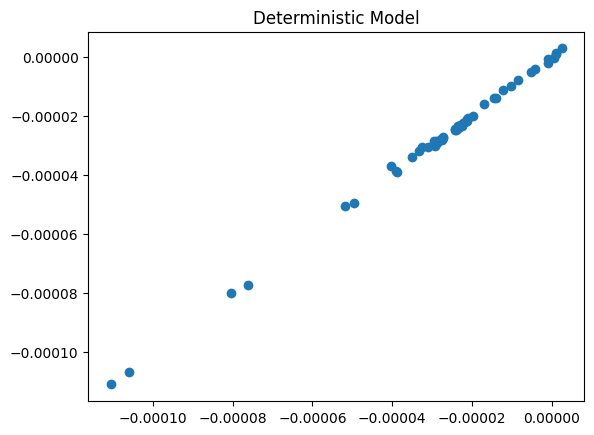

In [32]:
target = actual_target[:1, :1, 0:60]
preds = det_preds[:1, :1 , 0:60]

#show_r2(actual_target[:1, :, :], det_preds)

new_shape = (np.prod(target.shape[:-1]), target.shape[-1])
target_flattened = target.reshape(new_shape)
preds_flattened = preds.reshape(new_shape)

plt.scatter(target_flattened, preds_flattened)
plt.title('Deterministic Model')

Text(0.5, 1.0, 'Res Model')

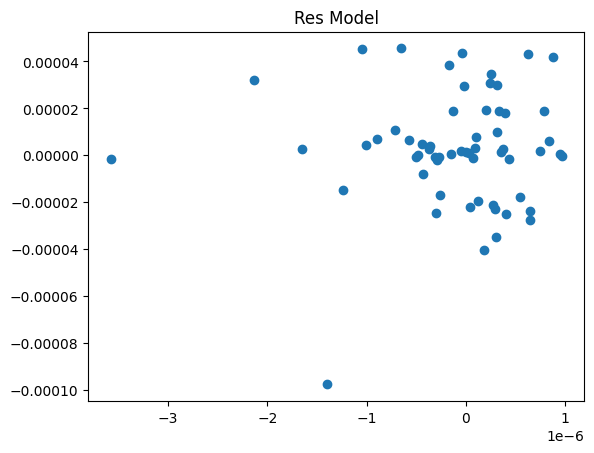

In [33]:
target =  actual_target[:1, :1, 0:60]- det_preds[:1, :1 , 0:60]
preds = res_stack[:1, :1 , 0:60]

#show_r2(actual_target[:1, :, :], det_preds)

new_shape = (np.prod(target.shape[:-1]), target.shape[-1])
target_flattened = target.reshape(new_shape)
preds_flattened = preds.reshape(new_shape)

plt.scatter(target_flattened, preds_flattened)
plt.title('Res Model')

Text(0.5, 1.0, 'Joint Model')

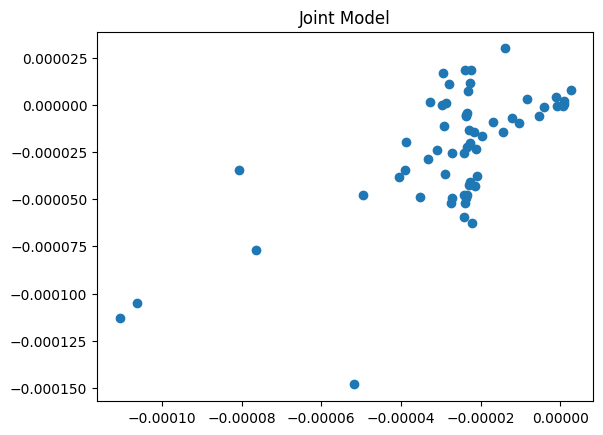

In [34]:
target = actual_target[:1, :1, 0:60]
preds = joint_preds[:1, :1 , 0:60]

#show_r2(actual_target[:1, :, :], det_preds)

new_shape = (np.prod(target.shape[:-1]), target.shape[-1])
target_flattened = target.reshape(new_shape)
preds_flattened = preds.reshape(new_shape)

plt.scatter(target_flattened, preds_flattened)
plt.title('Joint Model')

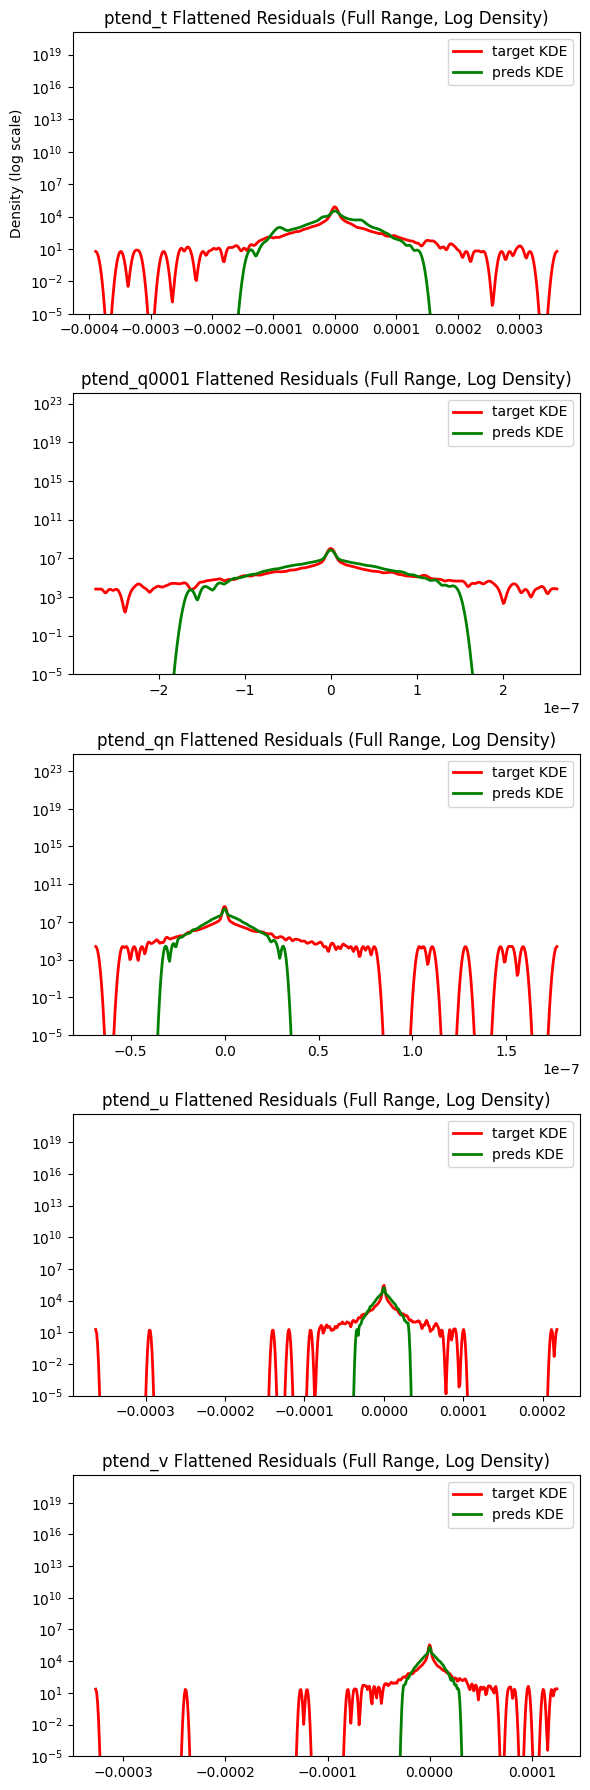

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

num_samples = 1
intervals = [
    (0, 60),
    (60, 120),
    (120, 180),
    (180, 240),
    (240, 300)
]

fig, axes = plt.subplots(5, 1, figsize=(6, 18), sharey=False)
titles = ['ptend_t','ptend_q0001','ptend_qn','ptend_u','ptend_v']

for i, (start, end) in enumerate(intervals):

    # ---- Extract the interval ----
    target_block = actual_target[:num_samples, :, start:end] - det_preds[:num_samples, :, start:end]
    preds_block  = joint_preds[:num_samples, :, start:end]  - det_preds[:num_samples, :, start:end]

    # Flatten
    t_flat = target_block.flatten()
    p_flat = preds_block.flatten()

    # Shared x‑range using full min/max
    low  = min(t_flat.min(), p_flat.min())
    high = max(t_flat.max(), p_flat.max())
    xs = np.linspace(low, high, 500)

    # KDEs
    kde_t = gaussian_kde(t_flat)
    kde_p = gaussian_kde(p_flat)

    ax = axes[i]

    # Plot KDE curves
    ax.plot(xs, kde_t(xs), color='red',   linewidth=2, label="target KDE")
    ax.plot(xs, kde_p(xs), color='green', linewidth=2, label="preds KDE")

    # Log scale for heavy‑tail visibility
    ax.set_yscale("log")

    # Cap the lower bound of the log axis
    ax.set_ylim(bottom=1e-5)

    ax.legend()
    ax.set_title(f"{titles[i]} Flattened Residuals (Full Range, Log Density)")
    if i == 0:
        ax.set_ylabel("Density (log scale)")

plt.tight_layout()
plt.show()


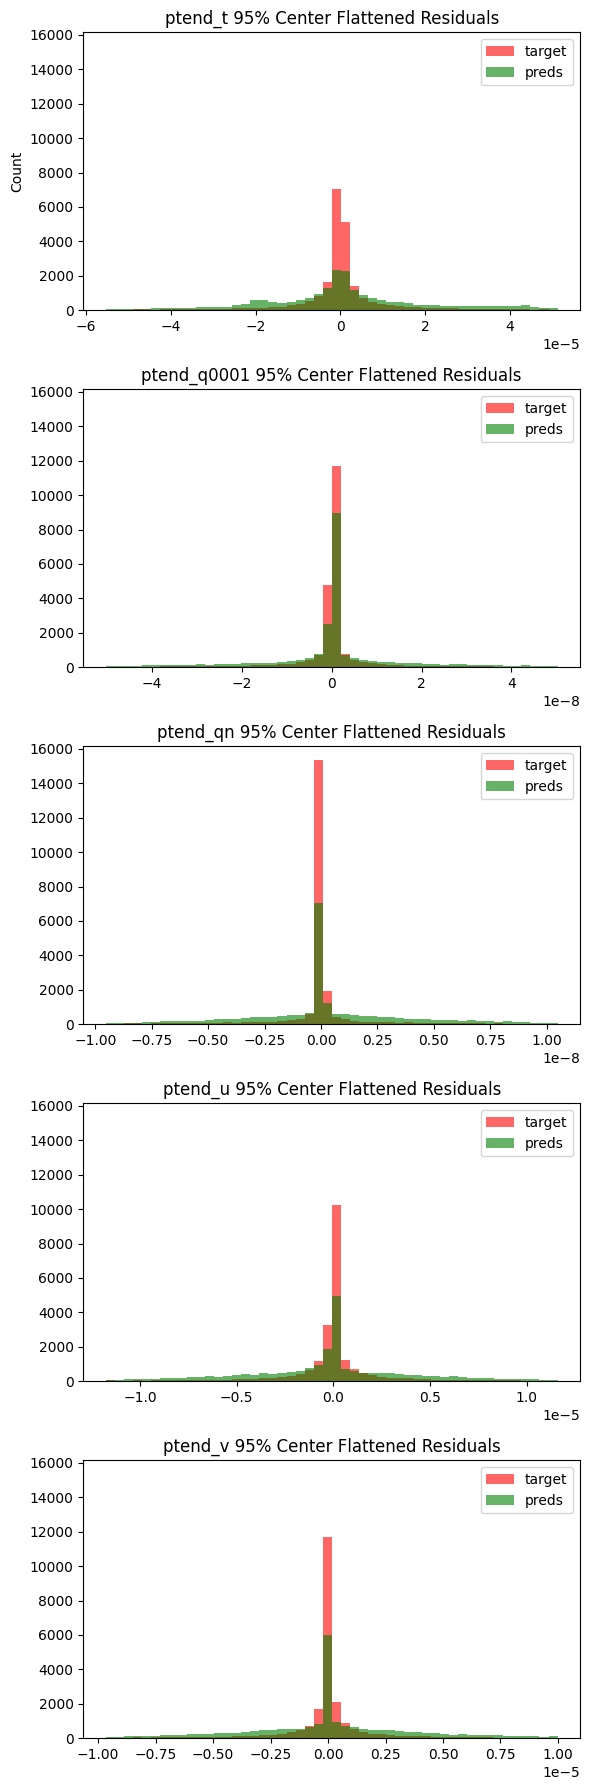

In [36]:
import numpy as np
import matplotlib.pyplot as plt

num_samples = 1
# interval boundaries
intervals = [
    (0, 60),
    (60, 120),
    (120, 180),
    (180, 240),
    (240, 300)
]

fig, axes = plt.subplots(5, 1, figsize=(6, 18), sharey=True)
titles = ['ptend_t','ptend_q0001',
                           'ptend_qn',
                           'ptend_u',
                           'ptend_v']
for i, (start, end) in enumerate(intervals):

    # ---- Extract the interval ----
    target_block = actual_target[:num_samples, :, start:end] - det_preds[:num_samples, :, start:end]
    preds_block  = joint_preds[:num_samples, :, start:end]  - det_preds[:num_samples, :, start:end]
    # Flatten
    t_flat = target_block.flatten()
    p_flat = preds_block.flatten()

    # ---- Compute shared 95% central range ----
    combined = np.concatenate([t_flat, p_flat])
    low  = np.percentile(combined, 2.5)
    high = np.percentile(combined, 97.5)

    # ---- Create bins ----
    num_bins = 50
    bin_edges = np.linspace(low, high, num_bins + 1)

    # ---- Plot ----
    ax = axes[i]
    ax.hist(t_flat, bins=bin_edges, alpha=0.6, color='red', label="target")
    ax.hist(p_flat, bins=bin_edges, alpha=0.6, color='green', label="preds")
    ax.legend()
    
    ax.set_title(f"{titles[i]} 95% Center Flattened Residuals")
    if i == 0:
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


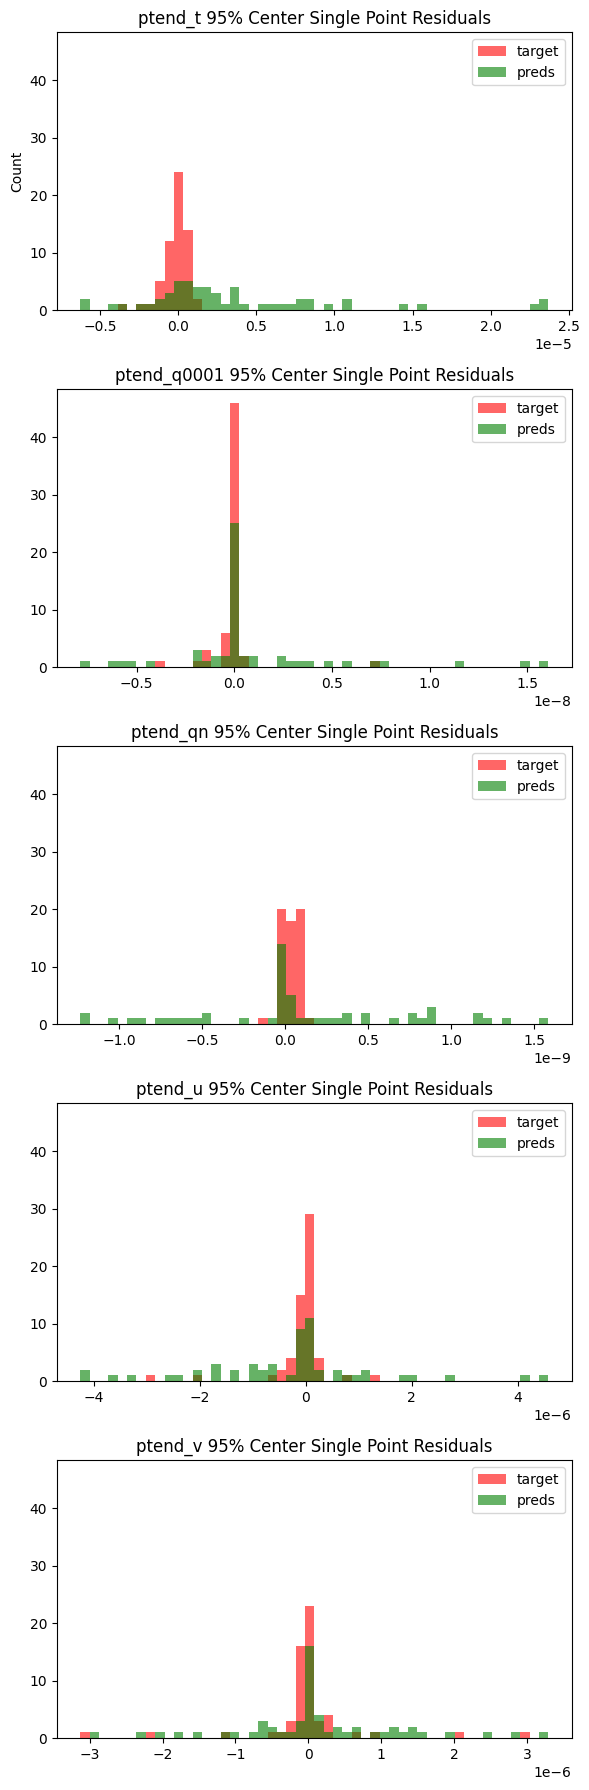

In [14]:
import numpy as np
import matplotlib.pyplot as plt

num_samples = 1
# interval boundaries
intervals = [
    (0, 60),
    (60, 120),
    (120, 180),
    (180, 240),
    (240, 300)
]

fig, axes = plt.subplots(5, 1, figsize=(6, 18), sharey=True)
titles = ['ptend_t','ptend_q0001',
                           'ptend_qn',
                           'ptend_u',
                           'ptend_v']
for i, (start, end) in enumerate(intervals):

    # ---- Extract the interval ----
    target_block = actual_target[:num_samples, :1, start:end] - det_preds[:num_samples, :1, start:end]
    preds_block  = joint_preds[:num_samples, :1, start:end]  - det_preds[:num_samples, :1, start:end]
    # Flatten
    t_flat = target_block.flatten()
    p_flat = preds_block.flatten()

    # ---- Compute shared 95% central range ----
    combined = np.concatenate([t_flat, p_flat])
    low  = np.percentile(combined, 2.5)
    high = np.percentile(combined, 97.5)

    # ---- Create bins ----
    num_bins = 50
    bin_edges = np.linspace(low, high, num_bins + 1)

    # ---- Plot ----
    ax = axes[i]
    ax.hist(t_flat, bins=bin_edges, alpha=0.6, color='red', label="target")
    ax.hist(p_flat, bins=bin_edges, alpha=0.6, color='green', label="preds")
    ax.legend()
    ax.set_title(f"{titles[i]} 95% Center Single Point Residuals")
    if i == 0:
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


In [37]:
#========Deterministic + Residual Model Prediciton=============

actual_target = np.array(actual_target)
#must used both preprocessed targets and preprocessed predictions
num_samples = joint_preds.shape[0]
joint_r2_scores, joint_r2_scores_capped = show_r2(actual_target[:num_samples, :, :],joint_preds)
#joint_zonal_heating_r2 = get_coeff(actual_target[:num_samples,:,:60], \ joint_preds[:,:,:60])


joint_zonal_heating_r2 = data.zonal_bin_weight_3d(get_coeff(actual_target[:num_samples,:,:60], \
                                                                      joint_preds[:,:,:60]))[0]
joint_zonal_moistening_r2 = data.zonal_bin_weight_3d(get_coeff(actual_target[:num_samples,:,60:120], \
                                                                          joint_preds[:,:,60:120]))[0]

#========Deterministic Model Prediciton=============


#must used both preprocessed targets and preprocessed predictions
num_samples = det_preds.shape[0]
det_r2_scores, det_r2_scores_capped = show_r2(actual_target[:num_samples, :, :], det_preds)


det_zonal_heating_r2 = data.zonal_bin_weight_3d(get_coeff(actual_target[:num_samples,:,:60], \
                                                                      det_preds[:,:,:60]))[0]
det_zonal_moistening_r2 = data.zonal_bin_weight_3d(get_coeff(actual_target[:num_samples,:,60:120], \
                                                                          det_preds[:,:,60:120]))[0]

/tmp/ipykernel_2016322/1540847125.py:15: RuntimeWarning: divide by zero encountered in divide
  coeff = 1 - rss/tss
/tmp/ipykernel_2016322/1540847125.py:15: RuntimeWarning: invalid value encountered in divide
  coeff = 1 - rss/tss
/tmp/ipykernel_2016322/1540847125.py:15: RuntimeWarning: divide by zero encountered in divide
  coeff = 1 - rss/tss
/tmp/ipykernel_2016322/1540847125.py:15: RuntimeWarning: invalid value encountered in divide
  coeff = 1 - rss/tss


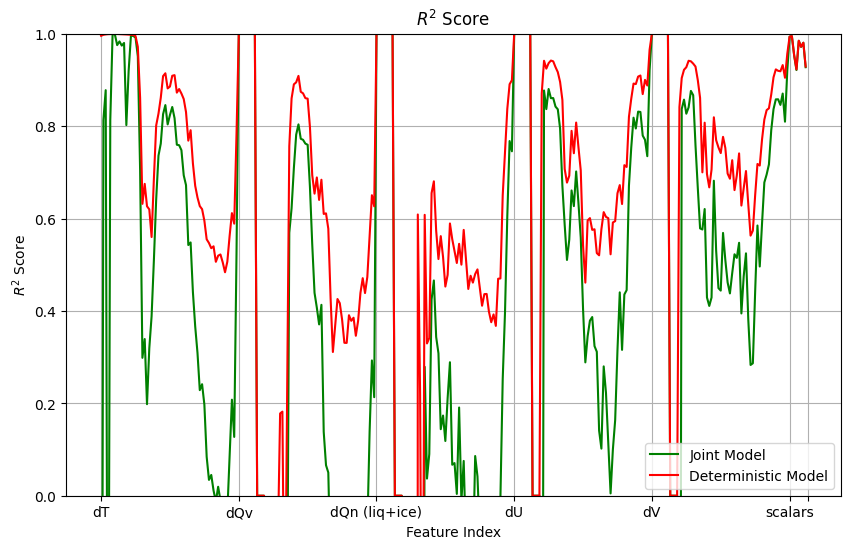

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(np.arange(data.target_feature_len), joint_r2_scores, color = 'green', label='Joint Model')
plt.plot(np.arange(data.target_feature_len), det_r2_scores, color = 'red', label='Deterministic Model')
    
plt.legend()
plt.xlabel('Feature Index')
plt.ylabel(r'$R^2$ Score')
plt.title(r'$R^2$ Score')

feature_indices = [0, 60, 120, 180, 240, 300, 308]
feature_labels = ['dT', 'dQv', 'dQn (liq+ice)', 'dU', 'dV', 'scalars', '']
plt.xticks(ticks=feature_indices, labels=feature_labels)
plt.ylim(0, 1)
plt.grid(True)

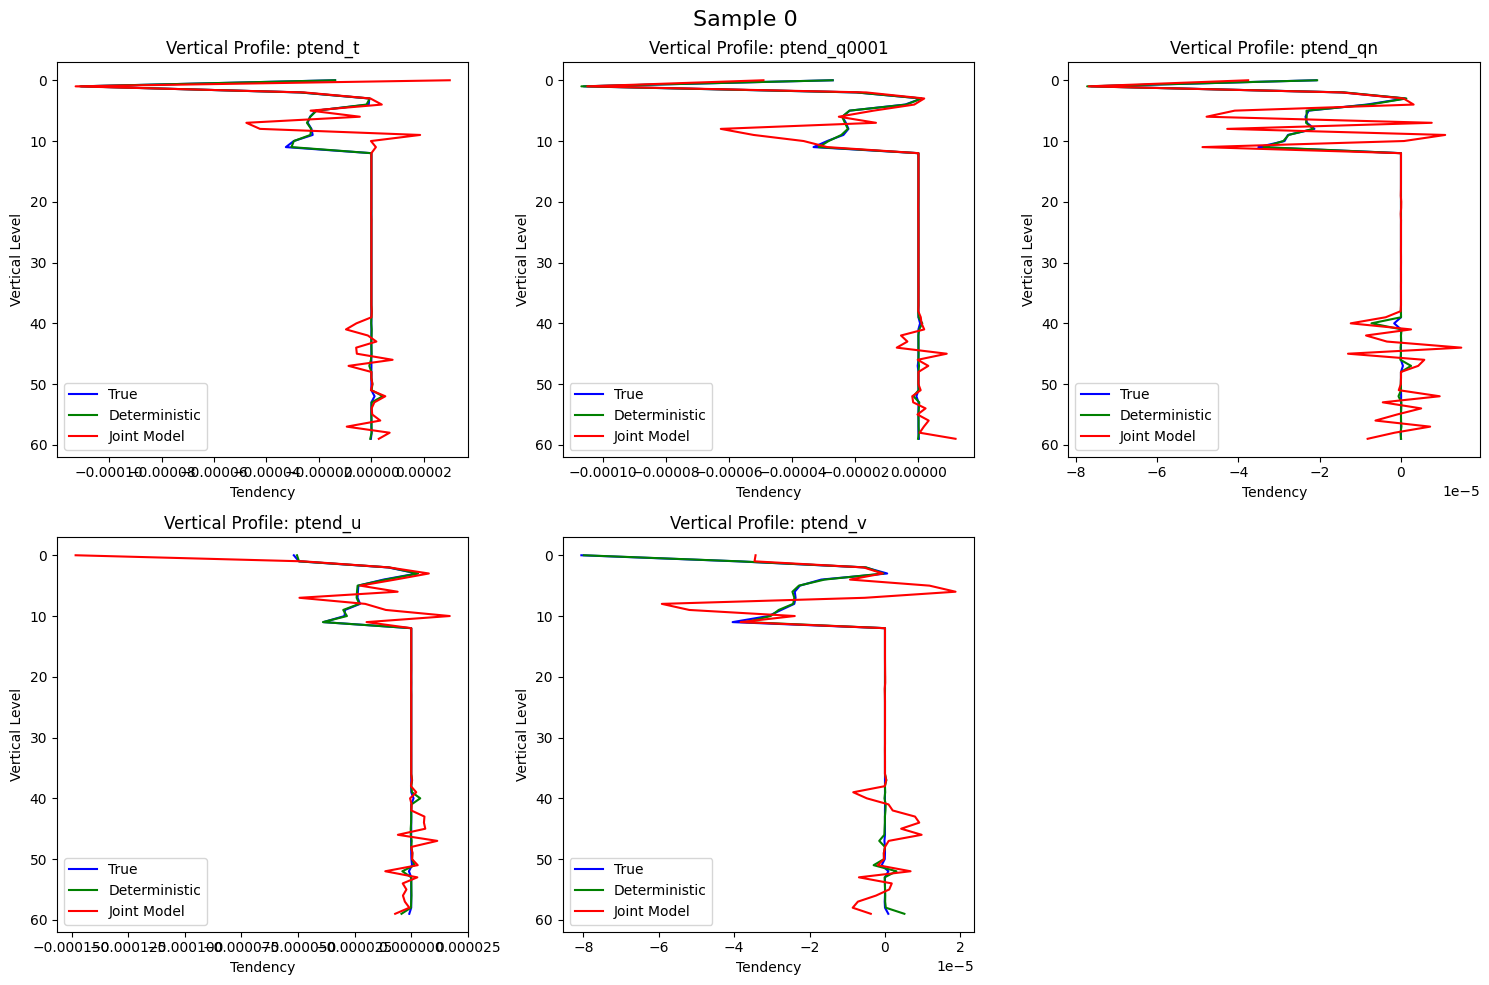

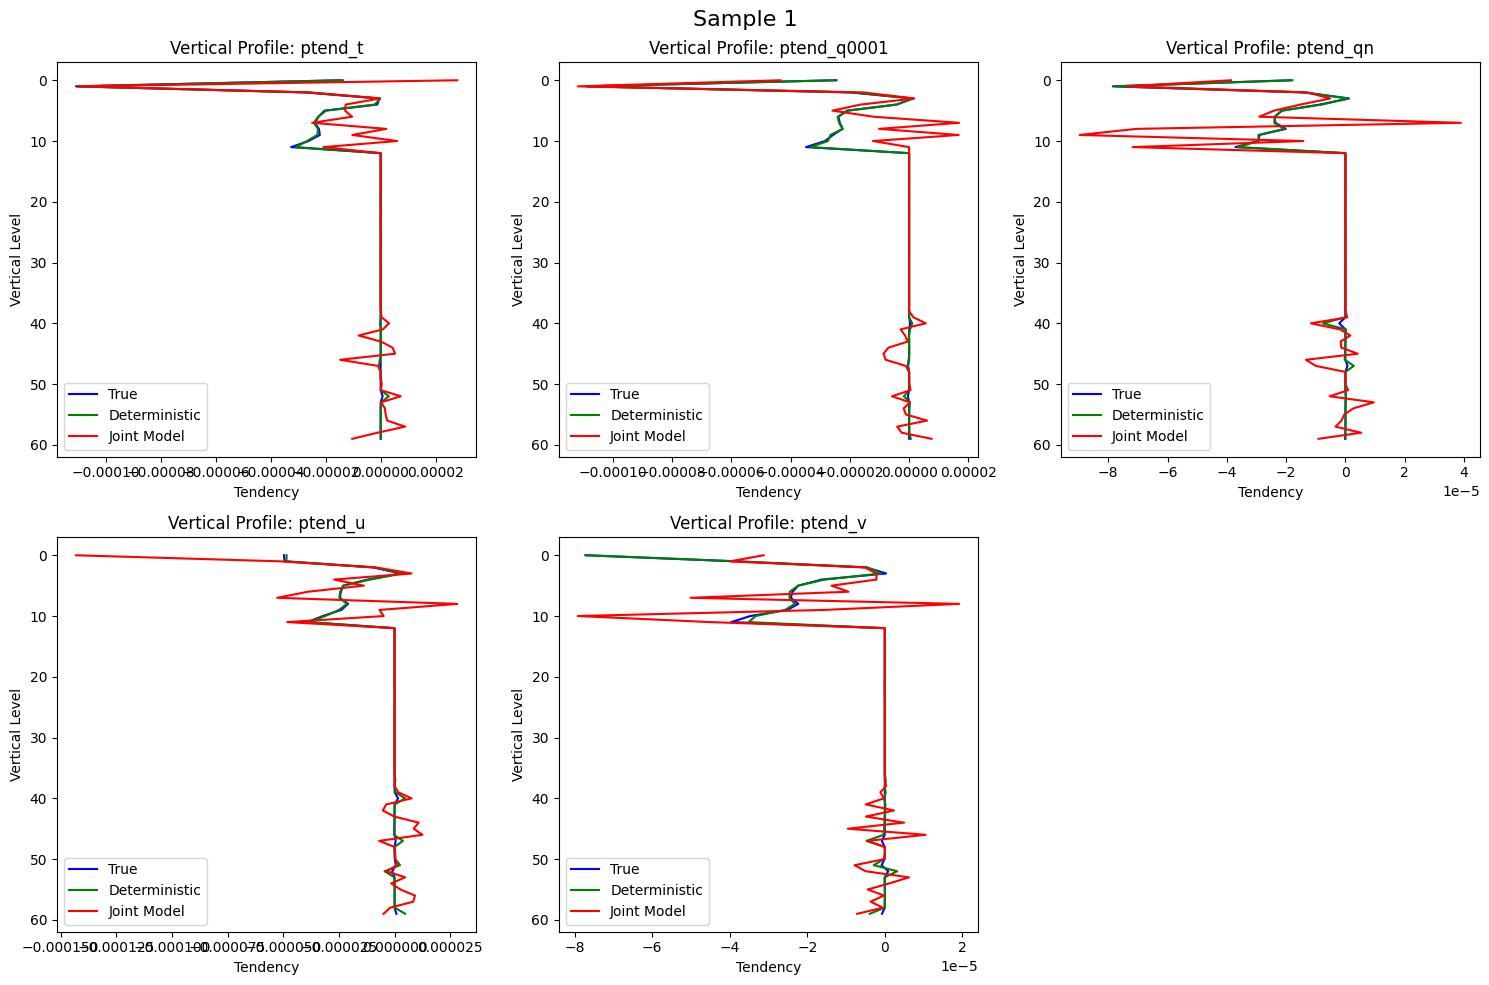

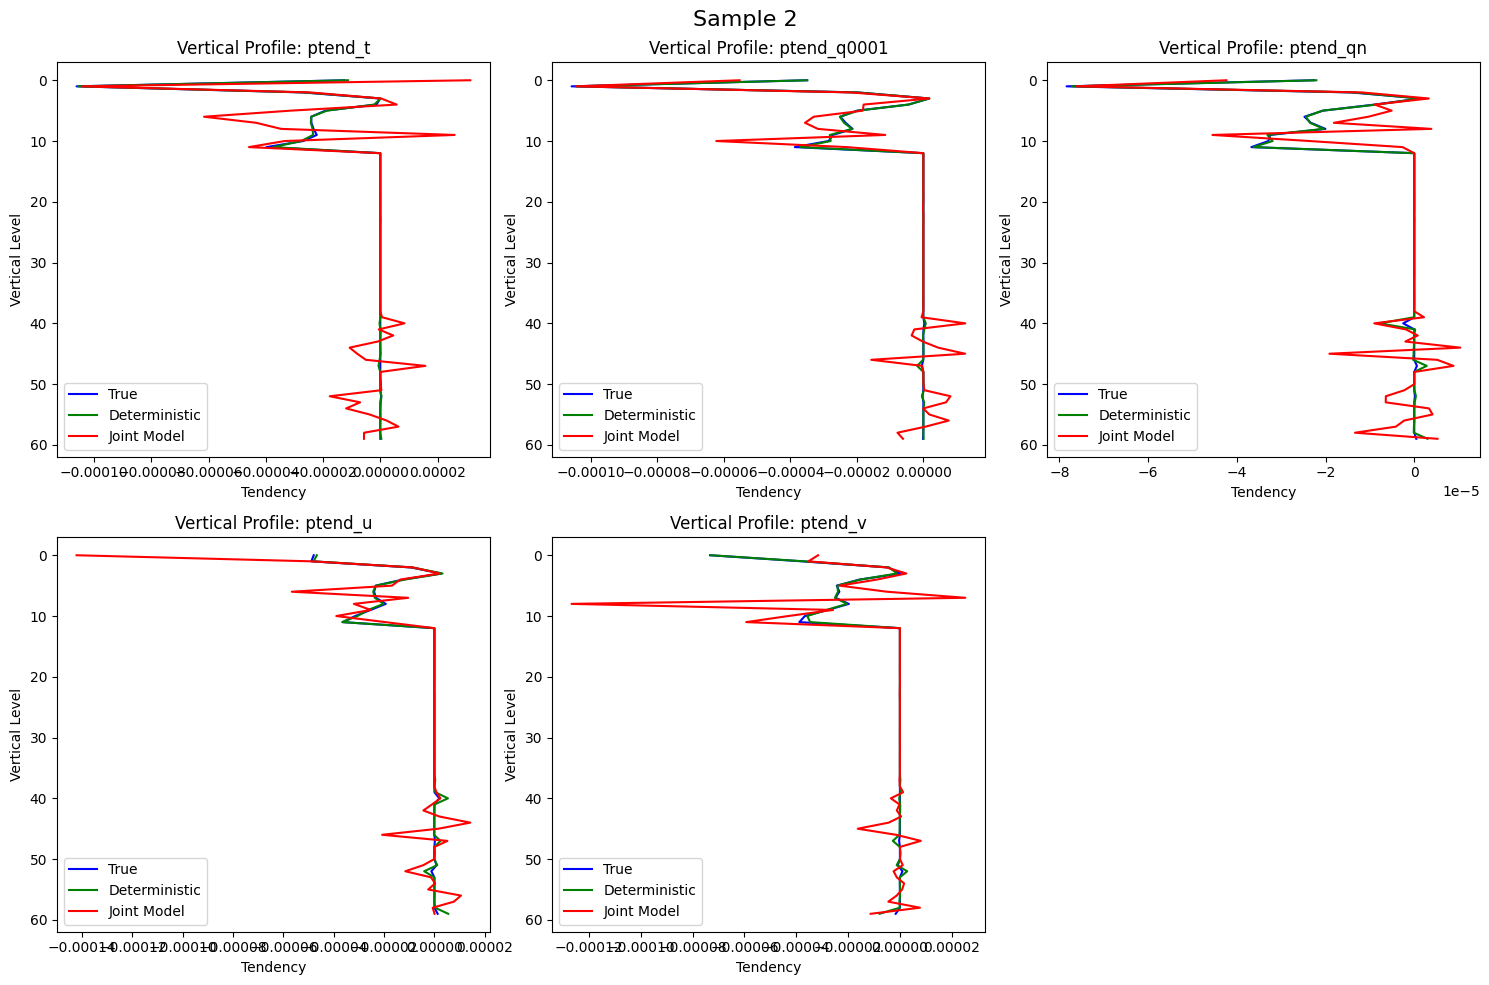

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Variable names for the 5 profile variables
var_names = ["ptend_t", "ptend_q0001", "ptend_qn", "ptend_u", "ptend_v"]

samples_to_plot = [0, 1, 2]   # three samples

column = 0      # column index

for sample in samples_to_plot:

    # Extract the 300 profile features and reshape
    true_block  = actual_target[sample, column, :300].reshape(60, 5)
    det_block   = det_preds[sample, column, :300].reshape(60, 5)
    joint_block = joint_preds[sample, column, :300].reshape(60, 5)

    levels = np.arange(60)

    # Create a single figure with 3x2 subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, name in enumerate(var_names):

        ax = axes[i]

        true_prof  = true_block[:, i]
        det_prof   = det_block[:, i]
        joint_prof = joint_block[:, i]

        ax.plot(true_prof,  levels, label="True", color='blue')
        ax.plot(det_prof,   levels, label="Deterministic", color='green')
        ax.plot(joint_prof, levels, label="Joint Model", color='red')

        ax.invert_yaxis()
        ax.set_xlabel("Tendency")
        ax.set_ylabel("Vertical Level")
        ax.set_title(f"Vertical Profile: {name}")
        ax.legend()

    # Hide the unused 6th subplot
    axes[-1].axis("off")

    fig.suptitle(f"Sample {sample}", fontsize=16)
    plt.tight_layout()
    plt.show()


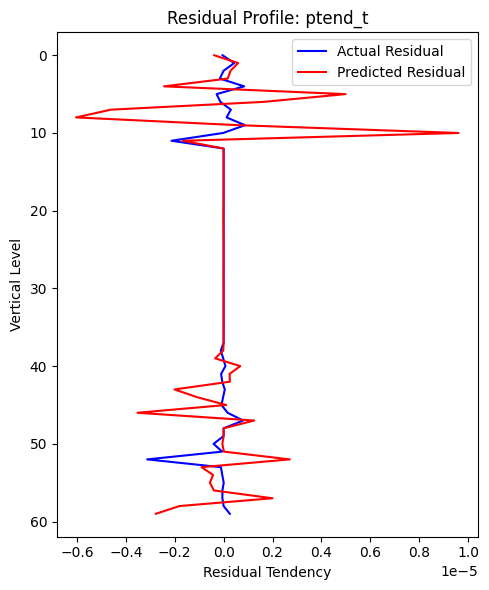

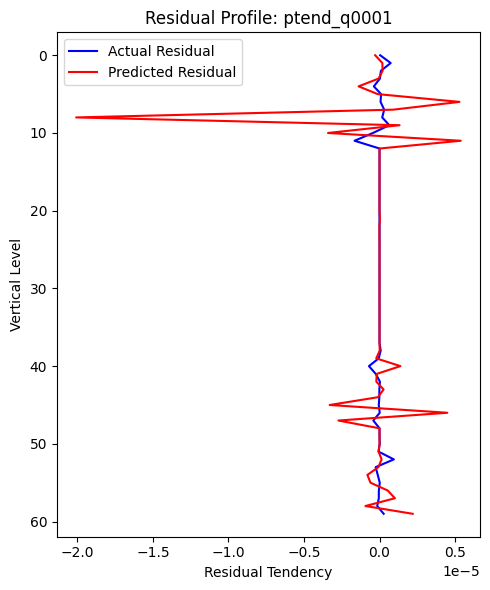

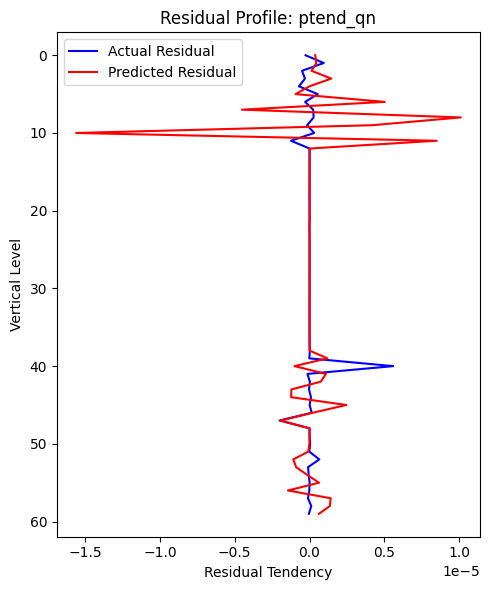

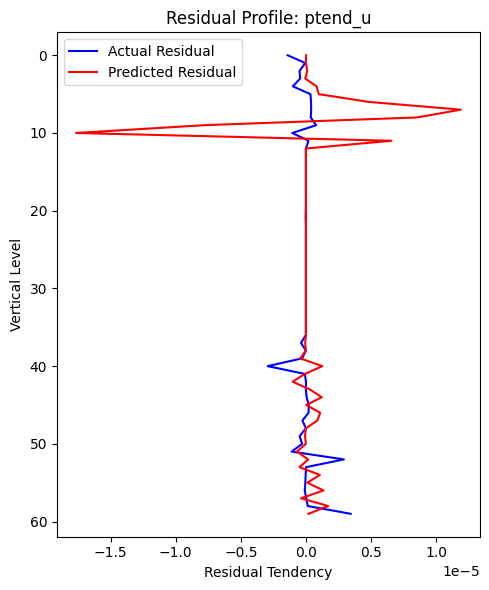

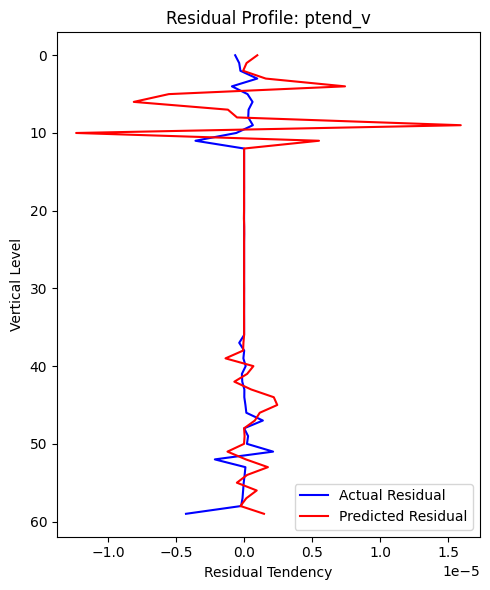

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Variable names for the 5 profile variables
var_names = ["ptend_t", "ptend_q0001", "ptend_qn", "ptend_u", "ptend_v"]

sample = 0      # batch index
column = 0      # column index

# Extract the 300 profile features and reshape into (60 levels, 5 variables)
true_block  = actual_target[sample, column, :300].reshape(60, 5)
det_block   = det_preds[sample, column, :300].reshape(60, 5)
joint_block = joint_preds[sample, column, :300].reshape(60, 5)

# Compute residuals
actual_residual  = true_block - det_block
predicted_residual = joint_block - det_block

levels = np.arange(60)

for i, name in enumerate(var_names):

    true_res  = actual_residual[:, i]
    pred_res  = predicted_residual[:, i]

    plt.figure(figsize=(5, 6))

    plt.plot(true_res, levels, label="Actual Residual", color='blue')
    plt.plot(pred_res, levels, label="Predicted Residual", color='red')

    plt.gca().invert_yaxis()
    plt.xlabel("Residual Tendency")
    plt.ylabel("Vertical Level")
    plt.title(f"Residual Profile: {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [47]:
'''
torch_input (B, C*L)
target (B, C*L)
'''

def inference_joint_model_batch(joint_model, torch_input, actual_input, target, pressures_binned,data,output_scale, debug_batch_override = None, latent_number = 10):
    #Load deterministic model
    joint_model.deterministic_model.eval()
    joint_model.res_model.eval()
    
    safe_std = torch.clamp(data.res_std, min=1e-2)
    
    det_list = []
    joint_list = []
    res_list = []

    #plain_det_list = []
    #plain_joint_list = []

    batch_size = data.num_latlon

    batch_i = 0
    
    with torch.no_grad():
        for i in tqdm(range(0, torch_input.shape[0], batch_size)):
            input_batch = torch_input[i : i + batch_size, :].to(device)
            target_batch = target[i : i + batch_size, :].to(device)
            if debug_batch_override != None and batch_i >= debug_batch_override:
                break
            batch_i += 1
            #print(f'data input shape is {data_input.squeeze(1).shape}')
            #print(f'data target shape is {target.squeeze(1).shape}')
            #batch = data_input[i:i+batch_size].to(device)
            #batch = torch_input[i*batch_size:i*batch_size+batch_size].to(device)


            #(B, C*L) --> (B,C,L)
            input_batch = joint_model.reshape_input(input_batch)

            #(B,C,L)
            output, latent_output = joint_model.deterministic_model(input_batch)
            
            #======Normalize input and condition data======
            condition_output = ((output -joint_model.preds_mean)/((joint_model.preds_std + 1e-8)))*.5

            if joint_model.condition_location == 'embedding':
                if joint_model.condition_type == 'input_output':
                    latent_condition = torch.cat((input_batch, condition_output), dim=1)
                else:
                    latent_condition = latent_output
                condition_data = latent_condition.reshape(latent_condition.shape[0], -1)
                
            elif joint_model.condition_location == 'middle' or joint_model.condition_location == 'cross':
                print('went here')
                if joint_model.condition_type == 'input_output':
                    latent_condition = torch.cat((input_batch, condition_output), dim=1)
                    print(latent_condition.shape)
                condition_data = latent_condition
            
            #(B,C,L) --> (B, C*L)
            reshaped_output = joint_model.reverse_reshape_target(output).cpu()
            #print(f'output shape is {output.shape}')
            reshaped_output = (reshaped_output.cpu()/output_scale).numpy()
            det_list.append(reshaped_output)

            #latents (B, C,L)
            print(condition_data.shape)
            latents = torch.randn((batch_size, data.target_profile_num + data.target_scalar_num, 64))
            latents = latents.to(device)


            res_latents_list = []
            joint_latents_list = []
            
            for n in range(latent_number):
                np.random.seed(n)
                #latents (B, C,L)
                #latents (B, C,L)
                
                sigma_min = .10
                sigma_max = 40
                B, C, L = output.shape
                safe_std = torch.clamp(joint_model.res_std, min=1e-2)
            
                condition_output = ((output -joint_model.preds_mean)/((joint_model.preds_std + 1e-8)))*.5

                #latents (B, C,L)
                latents = torch.randn((batch_size, data.target_profile_num + data.target_scalar_num, 64))
                latents = latents.to(device)
                
                #latent_condition = latent_condition.reshape(latent_condition.shape[0], -1)
                #condition_data = latent_condition
                    
                #res shape (B, C, L)
                res = joint_model.res_model.edm_sampler(latents, condition_input = condition_data, device = device, sigma_min=sigma_min, sigma_max=sigma_max, rho = 7) #maybe have to remove the last 4 meaningless levels??
                #rezeroes stratosphere levels
                denormalized_predicted_residual = (res/.5)*((safe_std+ 1e-8))
    
                #(B,C,L) --> (B, C*L)
                reshaped_res = joint_model.reverse_reshape_target(denormalized_predicted_residual).cpu()
                
                joint_pred = np.add(reshaped_output, reshaped_res)
                joint_pred[:, 300:] = torch.nn.functional.relu(torch.tensor(joint_pred[:, 300:]))
                #print(joint_pred[:, 300:])

                reshaped_res = (reshaped_res.cpu()/output_scale).numpy()
                res_latents_list.append(reshaped_res)
                
                #(B,C,L) --> (B, C*L)
                #joint_pred = joint_model.reverse_reshape_target(joint_pred)
                joint_pred = (joint_pred.cpu()/output_scale).numpy()
                joint_latents_list.append(joint_pred)

            res_latents_stack = np.stack(res_latents_list, axis = 0)
            joint_latents_stack = np.stack(joint_latents_list, axis = 0)

            res_list.append(res_latents_stack)
            joint_list.append(joint_latents_stack)
            
    det_stack = np.stack(det_list, axis=0)
    res_stack = np.stack(res_list, axis= 0)
    joint_stack = np.stack(joint_list, axis=0)


    gc.collect()
    torch.cuda.empty_cache()

    return det_stack, joint_stack, res_stack
    
    
    

In [48]:
det_stack, joint_stack, res_stack = inference_joint_model_batch(joint_model, torch_input,actual_input, torch.tensor(actual_target), pressures_binned, data,out_scale,                      
                                        debug_batch_override = 5, latent_number = 10)

  0%|          | 0/3754 [00:00<?, ?it/s]

went here
torch.Size([384, 39, 64])
torch.Size([384, 39, 64])


/tmp/ipykernel_2016322/2942623118.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  joint_pred[:, 300:] = torch.nn.functional.relu(torch.tensor(joint_pred[:, 300:]))
  0%|          | 1/3754 [00:17<18:21:22, 17.61s/it]

went here
torch.Size([384, 39, 64])
torch.Size([384, 39, 64])


  0%|          | 2/3754 [00:35<18:20:09, 17.59s/it]

...

  0%|          | 3/3754 [00:52<18:17:35, 17.56s/it]

went here
torch.Size([384, 39, 64])
torch.Size([384, 39, 64])


  0%|          | 4/3754 [01:10<18:17:56, 17.57s/it]

went here
torch.Size([384, 39, 64])
torch.Size([384, 39, 64])


  0%|          | 5/3754 [01:27<18:18:18, 17.58s/it]


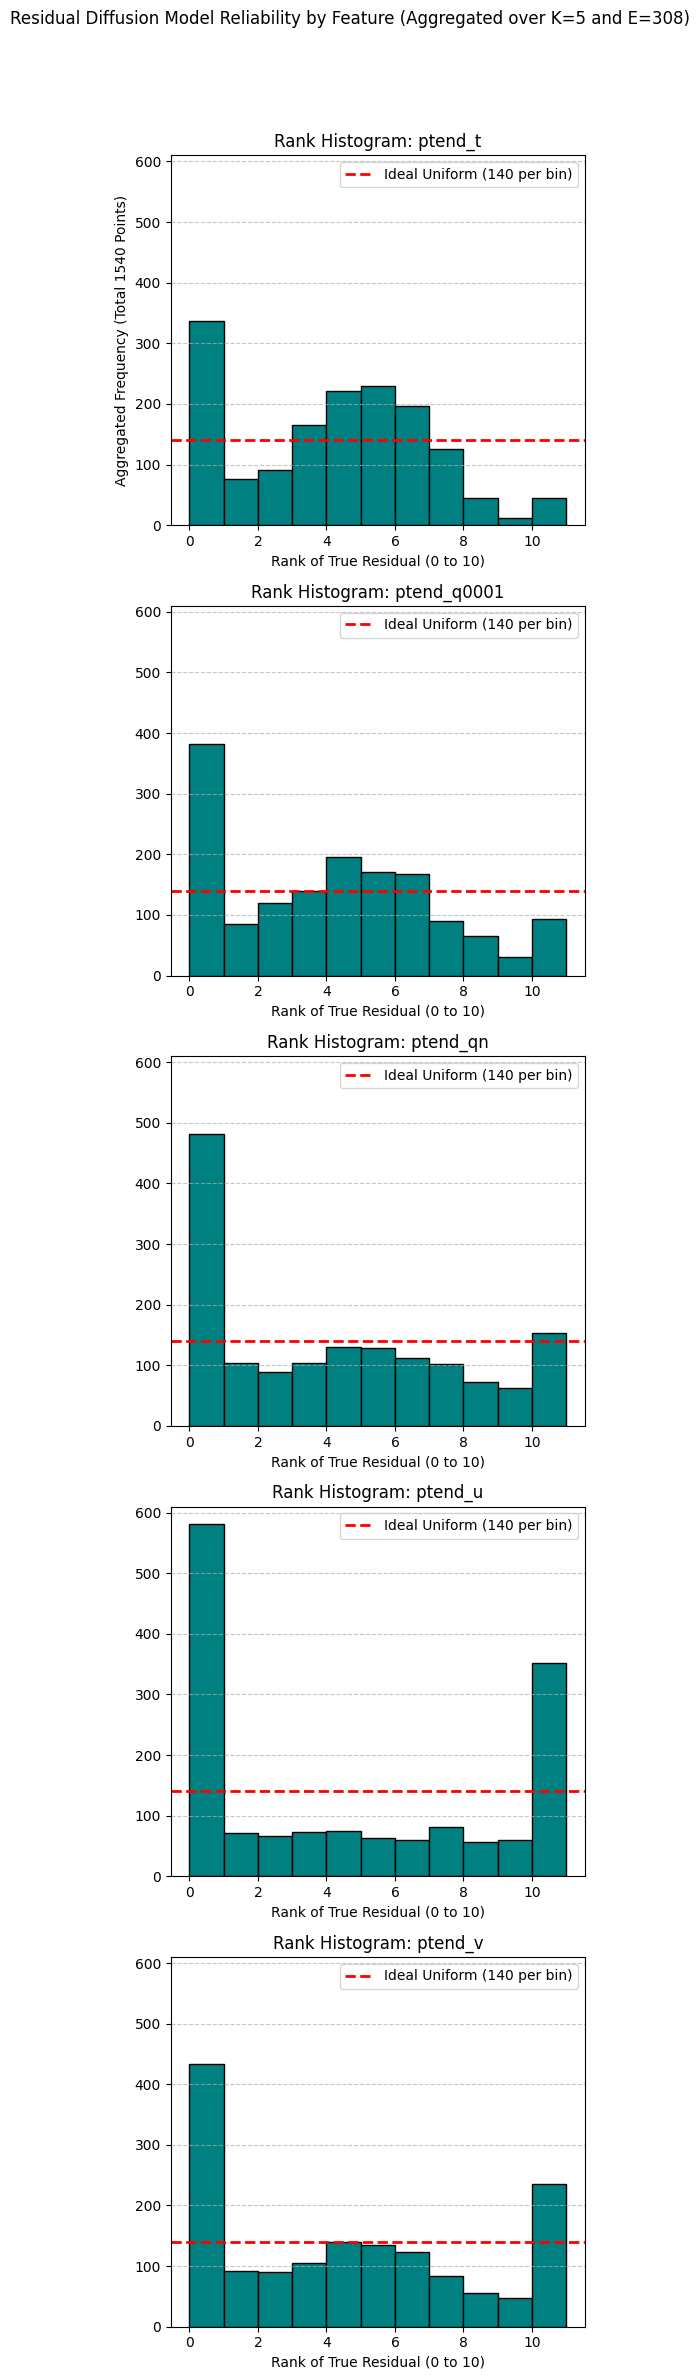

In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP & DATA INPUT ---
K_time, N_samples, F_count, E_levels = joint_stack.shape # K=Time/Cases, N=Ensemble Members, F=Features, E=Elevation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

det_stack = torch.tensor(det_stack)
joint_stack = torch.tensor(joint_stack)

# 2. CALCULATE TRUE RESIDUALS (R_O)
# R_O_actual: True Observation - Deterministic Forecast 
#R_O_actual = true_target - det_preds # Shape: [K, F, E]
#R_P_ensemble = joint_preds_list      # Predicted Residuals (Diffusion Samples) [K, N, F, E]
R_O_f_np=torch.tensor(actual_target[:K_time, :, :])-det_stack
R_P_f_np=joint_stack-(det_stack.unsqueeze(1).repeat(1, N_samples ,1,1))

# Get dimensions from the input
#K_time, N_samples, F_count, E_levels = R_P_ensemble.shape
P_agg = K_time * E_levels # Total points aggregated per feature (K * E)

all_feature_ranks = []
# Define feature names for plotting (adjust to match your model's outputs)
feature_names = ['ptend_t', 'ptend_q0001', 'ptend_qn', 'ptend_u', 'ptend_v', 
                 'Feature_6', 'Feature_7', 'Feature_8'] 


# --- 2. VECTORIZED RANK CALCULATION LOOP ---
#loops through the different features
for f in range(F_count):
    
    # 2.1 Reshape R_O (True Residuals) for feature 'f'
    # Slices R_O_actual[:, f, :] (K, E) then flattens to (P_agg)
    R_O_f = R_O_f_np[:, f, :].flatten() 

    # 2.2 Reshape R_P (Predicted Residuals) for feature 'f'
    # Slices R_P_ensemble[:, :, f, :] (K, N, E), permutes to (K, E, N), 
    # then reshapes K*E into P_agg -> (P_agg, N)
    R_P_f_reshaped = R_P_f_np[:, :, f, :].permute(0, 2, 1).reshape(P_agg, N_samples)
    
    # --- 2.3 Vectorized Rank Calculation ---
    
    # A. Prepare R_O for comparison: (P_agg) -> (P_agg, N)
    R_O_f_expanded = R_O_f.unsqueeze(1).expand_as(R_P_f_reshaped) 

    # B. Calculate Ranks: Sum of (Predicted Residual < True Residual) along the N dimension.
    # This gives the rank (0 to N) for each of the P_agg points.
    ranks_tensor = torch.sum(R_P_f_reshaped < R_O_f_expanded, dim=1) 

    # C. Convert to NumPy array for plotting
    ranks_np = ranks_tensor.cpu().numpy().astype(int)
    all_feature_ranks.append(ranks_np)


# --- 3. Plotting Function ---
def plot_feature_rank_histograms(all_feature_ranks, N, feature_names, K_time, E_levels):
    # Determine the number of features to plot (max 5)
    F_plot = min(len(all_feature_ranks), 5)
    ranks_to_plot = all_feature_ranks[:F_plot]
    names_to_plot = feature_names[:F_plot]
    
    fig, axes = plt.subplots(F_plot, 1, figsize=(5, 5 * F_plot), sharey=True)
    if F_plot == 1:
        axes = [axes] 

    bins = np.arange(N + 2) 
    total_samples_per_feature = K_time * E_levels

    for f, ranks in enumerate(ranks_to_plot):
        ax = axes[f]
        
        counts, _ = np.histogram(ranks, bins=bins)

        ax.bar(bins[:-1], counts, width=1.0, color='teal', edgecolor='black', align='edge')
        
        # Plot the ideal uniform line
        expected_count = total_samples_per_feature / (N + 1)
        ax.axhline(expected_count, color='red', linestyle='--', linewidth=2,
                   label=f'Ideal Uniform ({expected_count:.0f} per bin)')
        
        ax.set_title(f'Rank Histogram: {names_to_plot[f]}')
        ax.set_xlabel(f'Rank of True Residual (0 to {N})')
        # Set ticks intelligently: every 5th or 10th rank
        tick_step = max(1, N // 5)
        ax.set_xticks(np.arange(N + 1, step=tick_step))
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.legend()
    
    axes[0].set_ylabel(f'Aggregated Frequency (Total {total_samples_per_feature} Points)')

    plt.suptitle(f'Residual Diffusion Model Reliability by Feature (Aggregated over K={K_time} and E={E_levels})')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 4. EXECUTION ---
plot_feature_rank_histograms(all_feature_ranks, N_samples, feature_names, K_time, E_levels)

del all_feature_ranks, ranks_tensor, R_O_f_expanded, R_P_f_reshaped, R_O_f, P_agg
all_feature_ranks = []